In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/stacking-ml-models-fertilizers/__results__.html
/kaggle/input/stacking-ml-models-fertilizers/submission.csv
/kaggle/input/stacking-ml-models-fertilizers/__notebook__.ipynb
/kaggle/input/stacking-ml-models-fertilizers/__output__.json
/kaggle/input/stacking-ml-models-fertilizers/custom.css
/kaggle/input/stacking-ml-models-fertilizers/results/lgb_test.npy
/kaggle/input/stacking-ml-models-fertilizers/results/stacking_oof.npy
/kaggle/input/stacking-ml-models-fertilizers/results/lgb_goss_test.npy
/kaggle/input/stacking-ml-models-fertilizers/results/lgb_goss_oof.npy
/kaggle/input/stacking-ml-models-fertilizers/results/xgb_test.npy
/kaggle/input/stacking-ml-models-fertilizers/results/lgb_oof.npy
/kaggle/input/stacking-ml-models-fertilizers/results/stacking_test.npy
/kaggle/input/stacking-ml-models-fertilizers/results/xgb_oof.npy
/kaggle/input/stacking-ml-models-fertilizers/results/scores.txt
/kaggle/input/predicting-fertilizer-stacking-continued/__results__.html
/kaggle/input/pre

In [3]:
import os
os.environ['KAGGLE_CONFIG_DIR'] = '/kaggle/input/kagglejson'

In [4]:
!mkdir -p /kaggle/working/output
!kaggle kernels output bizen250/lightgbm-repeatedstratifiedkfold -p /kaggle/working/output

oof.npy: Skipping, found more recently modified local copy (use --force to force download)
pred.npy: Skipping, found more recently modified local copy (use --force to force download)
submission.csv: Skipping, found more recently modified local copy (use --force to force download)
Kernel log downloaded to /kaggle/working/output/lightgbm-repeatedstratifiedkfold.log 


In [5]:
!kaggle kernels output jaxa623/xgboost-repeatedstratifiedkfold -p /kaggle/working/output
!kaggle kernels output hahahaj/single-xgb -p /kaggle/working/output
!kaggle kernels output jaxa623/xgboost-repeatedstratifiedkfold -p /kaggle/working/output
!kaggle kernels output ayushchandramaurya/predicting-fertilizer-name-stacking-ensemble -p /kaggle/working/output
!kaggle kernels output qifeihhh666/predicting-optimal-fertilizers -p /kaggle/working/output
!kaggle kernels output kapilsuara05/predicting-optimal-fertilizers -p /kaggle/working/output

oof.npy: Skipping, found more recently modified local copy (use --force to force download)
pred.npy: Skipping, found more recently modified local copy (use --force to force download)
submission.csv: Skipping, found more recently modified local copy (use --force to force download)
Kernel log downloaded to /kaggle/working/output/xgboost-repeatedstratifiedkfold.log 
submission.csv: Skipping, found more recently modified local copy (use --force to force download)
xgb_repeat_test_oof.npy: Skipping, found more recently modified local copy (use --force to force download)
xgb_repeat_train_oof.npy: Skipping, found more recently modified local copy (use --force to force download)
Kernel log downloaded to /kaggle/working/output/single-xgb.log 
oof.npy: Skipping, found more recently modified local copy (use --force to force download)
pred.npy: Skipping, found more recently modified local copy (use --force to force download)
submission.csv: Skipping, found more recently modified local copy (use --f

Reference 

- https://www.kaggle.com/code/palfig/hill-climbing Hill climbing by Palfi G
- https://www.kaggle.com/code/cdeotte/gpu-hill-climbing-cv-0-05930 GPU Hill Climbing - [CV 0.05930] by Chris Deotte
- https://www.kaggle.com/competitions/playground-series-s5e5/discussion/576111 How To Ensemble with RMSLE
- https://www.kaggle.com/code/elainedazzio/20250628-pg6-rrf　RRF
- https://www.kaggle.com/code/hbugrae/blending-submissions-a-cluster-averaging-approach　Blending Submissions: A Cluster-Averaging Approach



In [10]:
train = pd.read_csv("/kaggle/input/playground-series-s5e6/train.csv")
le = LabelEncoder()
encoded = le.fit_transform(train['Fertilizer Name'])
true = encoded
train.head()
paths = []

paths.append("/kaggle/input/predicting-optimal-fertilizers-stacking/results")
paths.append("/kaggle/input/fertilizer-prediction")
paths.append("/kaggle/input/stacking-ml-models-fertilizers/results")
paths.append("/kaggle/input/xgboost-repeatedstratifiedkfold")
paths.append("/kaggle/input/predicting-fertilizer-stacking-continued/results_new/")
paths.append("/kaggle/working/output")
paths.append("/kaggle/working/output/results")

In [9]:
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import pandas as pd


In [11]:
# 데이터 로드 및 전처리
train = pd.read_csv("/kaggle/input/playground-series-s5e6/train.csv")
le = LabelEncoder()
encoded = le.fit_transform(train['Fertilizer Name'])
true = encoded

print(f"타겟 클래스 수: {len(np.unique(true))}")
print(f"학습 데이터 크기: {len(true)}")

# 경로 설정
paths = []
paths.append("/kaggle/input/predicting-optimal-fertilizers-stacking/results")
paths.append("/kaggle/input/fertilizer-prediction")
paths.append("/kaggle/input/stacking-ml-models-fertilizers/results")
paths.append("/kaggle/input/xgboost-repeatedstratifiedkfold")
paths.append("/kaggle/input/predicting-fertilizer-stacking-continued/results_new/")
paths.append("/kaggle/working/output")
paths.append("/kaggle/working/output/results")

타겟 클래스 수: 7
학습 데이터 크기: 750000


In [12]:
import numpy as np

# 만약 경로가 존재하면
path = "/kaggle/input/predicting-fertilizer-stacking-continued/results_new/lr_oof.npy"
if os.path.exists(path):
    data = np.load(path)
    print(data.shape)
else:
    print("파일이 존재하지 않습니다:", path)

(750000, 7)


In [13]:
# 1단계: OOF와 Test 예측 파일 로드
print("=" * 50)
print("1단계: 예측 파일 로드")
print("=" * 50)

x_train = []  # OOF 예측들
x_test = []   # Test 예측들
files = []    # 파일명 저장

for path in paths:
    print(f"\n경로 탐색 중: {path}")
    if not os.path.exists(path):
        print(f"경로가 존재하지 않습니다: {path}")
        continue
        
    for root, dirs, files_in_dir in os.walk(path):
        for file in files_in_dir:
            filepath = os.path.join(root, file)
            
            # .npy 파일만 처리
            if '.npy' not in filepath: 
                continue
                
            try:
                # OOF 파일 로드 (검증용)
                if 'oof' in filepath.lower():
                    print(f"  └ OOF 파일 로드: {file}")
                    oof_data = np.load(filepath)
                    
                    # 데이터 형태 확인 및 조정
                    if oof_data.ndim > 1:
                        oof_data = oof_data.flatten()
                    
                    x_train.append(oof_data)
                    files.append(file)
                    print(f"    크기: {oof_data.shape}")
                
                # Test 파일 로드 (제출용)
                elif any(keyword in filepath.lower() for keyword in ['test', 'pred', 'submission']):
                    print(f"  └ TEST 파일 로드: {file}")
                    pred_data = np.load(filepath)
                    
                    # 데이터 형태 확인 및 조정
                    if pred_data.ndim > 1:
                        pred_data = pred_data.flatten()
                    
                    x_test.append(pred_data)
                    print(f"    크기: {pred_data.shape}")
                    
            except Exception as e:
                print(f"  └ 파일 로드 실패 {file}: {e}")

print(f"\n로드 완료:")
print(f"  - OOF 파일 수: {len(x_train)}")
print(f"  - Test 파일 수: {len(x_test)}")

# 데이터가 없으면 종료
if len(x_train) == 0:
    print("OOF 파일을 찾을 수 없습니다. 경로와 파일명을 확인해주세요.")
    exit()

1단계: 예측 파일 로드

경로 탐색 중: /kaggle/input/predicting-optimal-fertilizers-stacking/results
  └ TEST 파일 로드: lgb_test.npy
    크기: (1750000,)
  └ OOF 파일 로드: stacking_oof.npy
    크기: (5250000,)
  └ TEST 파일 로드: lgb_goss_test.npy
    크기: (1750000,)
  └ OOF 파일 로드: lgb_goss_oof.npy
    크기: (5250000,)
  └ TEST 파일 로드: xgb_test.npy
    크기: (1750000,)
  └ OOF 파일 로드: lgb_oof.npy
    크기: (5250000,)
  └ TEST 파일 로드: stacking_test.npy
    크기: (1750000,)
  └ OOF 파일 로드: xgb_oof.npy
    크기: (5250000,)

경로 탐색 중: /kaggle/input/fertilizer-prediction
  └ TEST 파일 로드: lgb_test.npy
    크기: (1750000,)
  └ OOF 파일 로드: stacking_oof.npy
    크기: (5250000,)
  └ TEST 파일 로드: lgb_goss_test.npy
    크기: (1750000,)
  └ OOF 파일 로드: lgb_goss_oof.npy
    크기: (5250000,)
  └ TEST 파일 로드: xgb_test.npy
    크기: (1750000,)
  └ OOF 파일 로드: lgb_oof.npy
    크기: (5250000,)
  └ TEST 파일 로드: stacking_test.npy
    크기: (1750000,)
  └ OOF 파일 로드: xgb_oof.npy
    크기: (5250000,)

경로 탐색 중: /kaggle/input/stacking-ml-models-fertilizers/results
  └ TEST 파일 로

In [10]:
# 2단계: 데이터 형태 맞추기
print("\n" + "=" * 50)
print("2단계: 데이터 형태 조정")
print("=" * 50)

# OOF 데이터 스택
try:
    x_train = np.stack(x_train, axis=1)
    print(f"OOF 데이터 형태: {x_train.shape}")
    
    # 예상되는 형태와 맞는지 확인
    n_samples = len(true)
    n_classes = len(np.unique(true))
    
    # 데이터가 (n_samples * n_classes, n_models) 형태인지 확인
    if x_train.shape[0] == n_samples * n_classes:
        print(f"올바른 형태: 샘플 수 {n_samples} × 클래스 수 {n_classes} = {n_samples * n_classes}")
    else:
        print(f"경고: 예상 크기 {n_samples * n_classes}와 실제 크기 {x_train.shape[0]}가 다릅니다.")
        
except Exception as e:
    print(f"OOF 데이터 스택 실패: {e}")
    exit()

# Test 데이터 스택 (있는 경우)
if len(x_test) > 0:
    try:
        x_test = np.stack(x_test, axis=1)
        print(f"Test 데이터 형태: {x_test.shape}")
    except Exception as e:
        print(f"Test 데이터 스택 실패: {e}")
        x_test = None
else:
    x_test = None
    print("Test 예측 파일이 없습니다.")


2단계: 데이터 형태 조정
OOF 데이터 스택 실패: all input arrays must have the same shape
Test 데이터 형태: (1750000, 27)


# 수정버전

In [14]:
# 1단계: OOF와 Test 예측 파일 로드 (수정된 버전)
print("=" * 50)
print("1단계: 예측 파일 로드")
print("=" * 50)

x_train = []  # OOF 예측들
x_test = []   # Test 예측들
files = []    # 파일명 저장

# 예상되는 크기 미리 계산
n_samples = len(true)
n_classes = len(np.unique(true))
expected_oof_size = n_samples * n_classes  # 5250000
expected_test_size = 1750000  # test 크기

print(f"예상 OOF 크기: {expected_oof_size}")
print(f"예상 Test 크기: {expected_test_size}")

for path in paths:
    print(f"\n경로 탐색 중: {path}")
    if not os.path.exists(path):
        print(f"경로가 존재하지 않습니다: {path}")
        continue
        
    for root, dirs, files_in_dir in os.walk(path):
        for file in files_in_dir:
            filepath = os.path.join(root, file)
            
            # .npy 파일만 처리
            if '.npy' not in filepath: 
                continue
                
            try:
                # OOF 파일 로드 (검증용)
                if 'oof' in filepath.lower():
                    print(f"  └ OOF 파일 체크: {file}")
                    oof_data = np.load(filepath)
                    
                    # 데이터 형태 확인 및 조정
                    if oof_data.ndim > 1:
                        oof_data = oof_data.flatten()
                    
                    # 크기 검증: 예상 OOF 크기와 맞는지 확인
                    if len(oof_data) == expected_oof_size:
                        x_train.append(oof_data)
                        files.append(file)
                        print(f"    ✅ 로드 성공 - 크기: {oof_data.shape}")
                    else:
                        print(f"    ❌ 크기 불일치 - 예상: {expected_oof_size}, 실제: {len(oof_data)} (건너뜀)")
                
                # Test 파일 로드 (제출용)
                elif any(keyword in filepath.lower() for keyword in ['test', 'pred', 'submission']):
                    print(f"  └ TEST 파일 체크: {file}")
                    pred_data = np.load(filepath)
                    
                    # 데이터 형태 확인 및 조정
                    if pred_data.ndim > 1:
                        pred_data = pred_data.flatten()
                    
                    # 크기 검증: 예상 Test 크기와 맞는지 확인
                    if len(pred_data) == expected_test_size:
                        x_test.append(pred_data)
                        print(f"    ✅ 로드 성공 - 크기: {pred_data.shape}")
                    else:
                        print(f"    ❌ 크기 불일치 - 예상: {expected_test_size}, 실제: {len(pred_data)} (건너뜀)")
                    
            except Exception as e:
                print(f"  └ 파일 로드 실패 {file}: {e}")

print(f"\n로드 완료:")
print(f"  - 유효한 OOF 파일 수: {len(x_train)}")
print(f"  - 유효한 Test 파일 수: {len(x_test)}")

# 데이터가 없으면 종료
if len(x_train) == 0:
    print("유효한 OOF 파일을 찾을 수 없습니다. 경로와 파일명을 확인해주세요.")
    exit()

# 2단계: 데이터 형태 조정 (이제 문제없이 작동할 것)
print("\n" + "=" * 50)
print("2단계: 데이터 형태 조정")
print("=" * 50)

# OOF 데이터 스택 (이제 모든 크기가 동일함)
try:
    x_train = np.stack(x_train, axis=1)
    print(f"✅ OOF 데이터 형태: {x_train.shape}")
except Exception as e:
    print(f"OOF 데이터 스택 실패: {e}")
    exit()

# Test 데이터 스택 (있는 경우)
if len(x_test) > 0:
    try:
        x_test = np.stack(x_test, axis=1)
        print(f"✅ Test 데이터 형태: {x_test.shape}")
    except Exception as e:
        print(f"Test 데이터 스택 실패: {e}")
        x_test = None
else:
    x_test = None
    print("Test 예측 파일이 없습니다.")

1단계: 예측 파일 로드
예상 OOF 크기: 5250000
예상 Test 크기: 1750000

경로 탐색 중: /kaggle/input/predicting-optimal-fertilizers-stacking/results
  └ TEST 파일 체크: lgb_test.npy
    ✅ 로드 성공 - 크기: (1750000,)
  └ OOF 파일 체크: stacking_oof.npy
    ✅ 로드 성공 - 크기: (5250000,)
  └ TEST 파일 체크: lgb_goss_test.npy
    ✅ 로드 성공 - 크기: (1750000,)
  └ OOF 파일 체크: lgb_goss_oof.npy
    ✅ 로드 성공 - 크기: (5250000,)
  └ TEST 파일 체크: xgb_test.npy
    ✅ 로드 성공 - 크기: (1750000,)
  └ OOF 파일 체크: lgb_oof.npy
    ✅ 로드 성공 - 크기: (5250000,)
  └ TEST 파일 체크: stacking_test.npy
    ✅ 로드 성공 - 크기: (1750000,)
  └ OOF 파일 체크: xgb_oof.npy
    ✅ 로드 성공 - 크기: (5250000,)

경로 탐색 중: /kaggle/input/fertilizer-prediction
  └ TEST 파일 체크: lgb_test.npy
    ✅ 로드 성공 - 크기: (1750000,)
  └ OOF 파일 체크: stacking_oof.npy
    ✅ 로드 성공 - 크기: (5250000,)
  └ TEST 파일 체크: lgb_goss_test.npy
    ✅ 로드 성공 - 크기: (1750000,)
  └ OOF 파일 체크: lgb_goss_oof.npy
    ✅ 로드 성공 - 크기: (5250000,)
  └ TEST 파일 체크: xgb_test.npy
    ✅ 로드 성공 - 크기: (1750000,)
  └ OOF 파일 체크: lgb_oof.npy
    ✅ 로드 성공 - 크기: (525000

In [15]:
# 3단계: MAP@3 스코어 계산 함수
print("\n" + "=" * 50)
print("3단계: 평가 함수 정의")
print("=" * 50)

def map3_score_single(actual, predicted_flat, n_classes):
    """단일 모델의 MAP@3 스코어 계산"""
    n_samples = len(actual)
    
    # 예측을 (n_samples, n_classes) 형태로 변환
    pred = predicted_flat.reshape(n_samples, n_classes)
    
    # 상위 3개 클래스 선택
    top3 = np.argsort(-pred, axis=1)[:, :3]
    
    # 정답과 매칭
    matches = (top3 == actual[:, None])
    
    # MAP@3 가중치
    weights = np.array([1.0, 0.5, 1.0/3])
    scores = np.sum(matches * weights[None, :], axis=1)
    
    return np.mean(scores)

def multiple_map3_scores(actual, predicted_array, n_classes):
    """여러 모델의 MAP@3 스코어를 한번에 계산"""
    n_models = predicted_array.shape[1]
    scores = np.zeros(n_models)
    
    for i in range(n_models):
        scores[i] = map3_score_single(actual, predicted_array[:, i], n_classes)
    
    return scores


3단계: 평가 함수 정의


In [16]:
# 4단계: 개별 모델 성능 확인
print("\n" + "=" * 50)
print("4단계: 개별 모델 성능 평가")
print("=" * 50)

n_classes = len(np.unique(true))
print(f"클래스 수: {n_classes}")

best_score = 0
best_index = -1

for k, name in enumerate(files):
    try:
        score = map3_score_single(true, x_train[:, k], n_classes)
        print(f"MAP@3 {score:0.5f} - {name}")
        
        if score > best_score:
            best_score = score
            best_index = k
    except Exception as e:
        print(f"모델 {name} 평가 실패: {e}")

print(f"\n최고 성능 모델: {files[best_index]} (MAP@3: {best_score:0.5f})")


4단계: 개별 모델 성능 평가
클래스 수: 7
MAP@3 0.37817 - stacking_oof.npy
MAP@3 0.36902 - lgb_goss_oof.npy
MAP@3 0.37459 - lgb_oof.npy
MAP@3 0.37595 - xgb_oof.npy
MAP@3 0.37842 - stacking_oof.npy
MAP@3 0.36943 - lgb_goss_oof.npy
MAP@3 0.37485 - lgb_oof.npy
MAP@3 0.37675 - xgb_oof.npy
MAP@3 0.37788 - stacking_oof.npy
MAP@3 0.36885 - lgb_goss_oof.npy
MAP@3 0.37427 - lgb_oof.npy
MAP@3 0.37546 - xgb_oof.npy
MAP@3 0.36990 - oof.npy
MAP@3 0.33792 - cat_oof.npy
MAP@3 0.28847 - mlp_oof.npy
MAP@3 0.37706 - stacking_oof_new.npy
MAP@3 0.28544 - lr_oof.npy
MAP@3 0.37044 - oof.npy
MAP@3 0.37634 - xgb_repeat_train_oof.npy
MAP@3 0.37869 - stacking_oof.npy
MAP@3 0.37496 - lgb_oof.npy
MAP@3 0.36937 - lgb_goss_oof.npy
MAP@3 0.37675 - xgb_oof.npy
MAP@3 0.37869 - stacking_oof.npy
MAP@3 0.37496 - lgb_oof.npy
MAP@3 0.36937 - lgb_goss_oof.npy
MAP@3 0.37675 - xgb_oof.npy

최고 성능 모델: stacking_oof.npy (MAP@3: 0.37869)


In [18]:
# 5단계: 힐클라이밍 실행
print("\n" + "=" * 50)
print("5단계: 힐클라이밍 시작")
print("=" * 50)

# 파라미터 설정
USE_NEGATIVE_WGT = True
MAX_MODELS = min(50, len(files))  # 최대 모델 수 제한
TOL = 1e-5  # 허용 오차

# 가중치 범위 설정
start = -0.50 if USE_NEGATIVE_WGT else 0.02
weights_range = np.arange(start, 0.6, 0.02)
print(f"가중치 범위: {start:.2f} ~ 0.60 (간격: 0.02)")
print(f"최대 모델 수: {MAX_MODELS}")

# 초기화
best_ensemble = x_train[:, best_index].copy()
old_best_score = best_score
models_used = [best_index]
model_weights = []
score_history = [best_score]

print(f"0. 시작 모델: {files[best_index]} (MAP@3: {best_score:0.5f})")

# 힐클라이밍 메인 루프
for iteration in range(MAX_MODELS - 1):
    current_best_score = 0
    current_best_index = -1
    current_best_weight = 0
    
    # 각 모델에 대해 최적 가중치 탐색
    for k, model_name in enumerate(files):
        if k in models_used:  # 이미 사용된 모델은 스킵
            continue
            
        try:
            # 새로운 모델과 현재 앙상블 조합
            new_model = x_train[:, k]
            
            # 다양한 가중치로 테스트
            scores = []
            for w in weights_range:
                combined = (1 - w) * best_ensemble + w * new_model
                score = map3_score_single(true, combined, n_classes)
                scores.append(score)
            
            # 최고 성능 가중치 찾기
            max_score = max(scores)
            if max_score > current_best_score:
                current_best_score = max_score
                current_best_index = k
                best_weight_idx = np.argmax(scores)
                current_best_weight = weights_range[best_weight_idx]
                
        except Exception as e:
            print(f"  모델 {model_name} 테스트 실패: {e}")
            continue
    
    # 개선이 없으면 중단
    if current_best_index == -1 or (current_best_score - old_best_score) < TOL:
        print(f"  └ 개선 없음 (차이: {current_best_score - old_best_score:.6f} < {TOL})")
        break
    
    # 새로운 최고 조합 업데이트
    new_model = x_train[:, current_best_index]
    best_ensemble = (1 - current_best_weight) * best_ensemble + current_best_weight * new_model
    
    models_used.append(current_best_index)
    model_weights.append(current_best_weight)
    score_history.append(current_best_score)
    old_best_score = current_best_score
    
    print(f"{iteration + 1:2d}. 추가: {files[current_best_index][:50]}")
    print(f"    가중치: {current_best_weight:0.3f}, MAP@3: {current_best_score:0.5f} (+{current_best_score - score_history[-2]:0.5f})")


5단계: 힐클라이밍 시작
가중치 범위: -0.50 ~ 0.60 (간격: 0.02)
최대 모델 수: 27
0. 시작 모델: stacking_oof.npy (MAP@3: 0.37869)
 1. 추가: oof.npy
    가중치: 0.220, MAP@3: 0.37952 (+0.00083)
 2. 추가: stacking_oof.npy
    가중치: 0.360, MAP@3: 0.37990 (+0.00038)
 3. 추가: lgb_goss_oof.npy
    가중치: 0.080, MAP@3: 0.38008 (+0.00018)
 4. 추가: mlp_oof.npy
    가중치: 0.100, MAP@3: 0.38020 (+0.00013)
 5. 추가: stacking_oof.npy
    가중치: 0.100, MAP@3: 0.38026 (+0.00006)
 6. 추가: xgb_oof.npy
    가중치: 0.100, MAP@3: 0.38028 (+0.00002)
  └ 개선 없음 (차이: 0.000006 < 1e-05)


In [19]:
# 6단계: 최종 가중치 계산 및 결과 출력
print("\n" + "=" * 50)
print("6단계: 최종 결과")
print("=" * 50)

# 최종 가중치 계산
final_weights = np.array([1.0])  # 첫 번째 모델
for w in model_weights:
    final_weights = final_weights * (1 - w)
    final_weights = np.append(final_weights, w)

# 결과 정리
results = []
for i, (model_idx, weight) in enumerate(zip(models_used, final_weights)):
    results.append({
        'model': files[model_idx],
        'weight': weight,
        'order': i + 1
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('weight', ascending=False).reset_index(drop=True)

print("최종 앙상블 구성:")
print(results_df)
print(f"\n가중치 합계: {results_df['weight'].sum():.6f}")
print(f"최종 MAP@3 스코어: {old_best_score:.6f}")
print(f"개선: +{old_best_score - best_score:.6f}")


6단계: 최종 결과
최종 앙상블 구성:
              model    weight  order
0  stacking_oof.npy  0.334803      1
1  stacking_oof.npy  0.241445      3
2       xgb_oof.npy  0.100000      7
3           oof.npy  0.094432      2
4  stacking_oof.npy  0.090000      6
5       mlp_oof.npy  0.081000      5
6  lgb_goss_oof.npy  0.058320      4

가중치 합계: 1.000000
최종 MAP@3 스코어: 0.380280
개선: +0.001589


In [20]:
# 7단계: Test 예측 생성 (Test 데이터가 있는 경우)
if x_test is not None:
    print("\n" + "=" * 50)
    print("7단계: Test 예측 생성")
    print("=" * 50)
    
    # Test 데이터로 앙상블 예측
    test_ensemble = x_test[:, models_used[0]] * final_weights[0]
    for i in range(1, len(models_used)):
        test_ensemble += x_test[:, models_used[i]] * final_weights[i]
    
    # 예측 결과를 (n_samples, n_classes) 형태로 변환
    n_test_samples = x_test.shape[0] // n_classes
    test_pred = test_ensemble.reshape(n_test_samples, n_classes)
    
    # 상위 3개 클래스 선택
    top3_indices = np.argsort(test_pred, axis=1)[:, -3:][:, ::-1]
    top3_categories = le.inverse_transform(top3_indices.flatten()).reshape(-1, 3)
    
    # 제출 파일 생성
    submission = pd.read_csv('/kaggle/input/playground-series-s5e6/sample_submission.csv')
    submission['Fertilizer Name'] = [' '.join(row) for row in top3_categories]
    submission.to_csv('hill_climbing_submission.csv', index=False)
    
    print("제출 파일 생성 완료: hill_climbing_submission.csv")
    print(f"예측 샘플 수: {len(submission)}")
    print(f"Top 3 예측 예시:")
    print(submission.head())


7단계: Test 예측 생성
제출 파일 생성 완료: hill_climbing_submission.csv
예측 샘플 수: 250000
Top 3 예측 예시:
       id         Fertilizer Name
0  750000      10-26-26 20-20 DAP
1  750001  17-17-17 10-26-26 Urea
2  750002          Urea 20-20 DAP
3  750003  14-35-14 Urea 10-26-26
4  750004     Urea 20-20 10-26-26



8단계: 결과 시각화


/usr/local/lib/python3.11/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from current font.
  func(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 53076 (\N{HANGUL SYLLABLE KO}) missing from current font.
  func(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 50612 (\N{HANGUL SYLLABLE EO}) missing from current font.
  func(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 55184 (\N{HANGUL SYLLABLE HIL}) missing from current font.
  func(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from current font.
  func(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 46972 (\N{HANGUL SYLLABLE RA}) missing from current font.
  func(*args

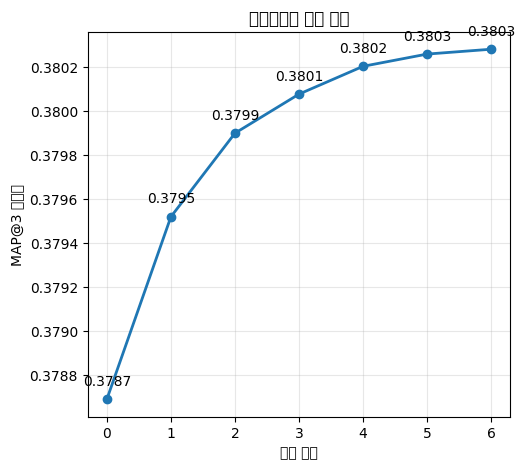

In [21]:
# 8단계: 성능 시각화
print("\n" + "=" * 50)
print("8단계: 결과 시각화")
print("=" * 50)

# 성능 향상 그래프
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(len(score_history)), score_history, 'o-', linewidth=2, markersize=6)
plt.title('힐클라이밍 성능 향상')
plt.xlabel('반복 횟수')
plt.ylabel('MAP@3 스코어')
plt.grid(True, alpha=0.3)
for i, score in enumerate(score_history):
    plt.annotate(f'{score:.4f}', (i, score), textcoords="offset points", xytext=(0,10), ha='center')



In [ ]:
# 모델 가중치 분포
plt.subplot(1, 2, 2)
model_names = [files[i][:20] + '...' if len(files[i]) > 20 else files[i] for i in models_used]
colors = plt.cm.Set3(np.linspace(0, 1, len(final_weights)))
bars = plt.bar(range(len(final_weights)), final_weights, color=colors)
plt.title('모델별 가중치 분포')
plt.xlabel('모델')
plt.ylabel('가중치')
plt.xticks(range(len(final_weights)), [f'M{i+1}' for i in range(len(final_weights))], rotation=45)
plt.grid(True, alpha=0.3)



In [ ]:
# 가중치 값 표시
for i, (bar, weight) in enumerate(zip(bars, final_weights)):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01, 
             f'{weight:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\n힐클라이밍 완료!")
print(f"사용된 모델 수: {len(models_used)}")
print(f"최종 성능: {old_best_score:.6f}")
print(f"시작 대비 개선: +{old_best_score - best_score:.6f} ({((old_best_score/best_score - 1) * 100):+.2f}%)")